In [12]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from rdkit import Chem

import yaml

import sys
sys.path.append("..")

from synflownet.data.async_sql_databases import PersistentReplayBuffer, RewardQueue, RewardCache
from scripts.boltz_reward_worker import parse_info

# Monitor the size of Reward Queue and Replay Buffer

In [2]:
config_path = "../configs/TYK2_config.yaml"
with open(config_path) as f:
    sfn_boltz_cfg = yaml.safe_load(f)

display(sfn_boltz_cfg)

# if the path is relative to the config
# we assume the running directory to be the synflownet-boltz-launcher directory
if not Path(sfn_boltz_cfg["reward_queue_path"]).is_absolute():
    sfn_boltz_cfg["reward_queue_path"] = Path(os.getcwd()).parent / sfn_boltz_cfg["reward_queue_path"]
    print("Reset reward queue path on top of synflownet-boltz-launcher directory")
if not Path(sfn_boltz_cfg["persistent_replay_path"]).is_absolute():
    sfn_boltz_cfg["persistent_replay_path"] = Path(os.getcwd()).parent / sfn_boltz_cfg["persistent_replay_path"]
    print("Reset persistent replay path on top of synflownet-boltz-launcher directory")
if not Path(sfn_boltz_cfg["reward_cache_path"]).is_absolute():
    sfn_boltz_cfg["reward_cache_path"] = Path(os.getcwd()).parent / sfn_boltz_cfg["reward_cache_path"]
    print("Reset reward cache path on top of synflownet-boltz-launcher directory")


{'target': 'TYK2',
 'reward_queue_path': './dbs/reward_queue.db',
 'persistent_replay_path': './dbs/replay_buffer.db',
 'reward_cache_path': './dbs/reward_cache.db',
 'reward_queue_max_size': 5000,
 'persistent_replay_max_size': 10000000,
 'worker_batch_size': 20}

Reset reward queue path on top of synflownet-boltz-launcher directory
Reset persistent replay path on top of synflownet-boltz-launcher directory
Reset reward cache path on top of synflownet-boltz-launcher directory


In [ ]:
reward_queue = RewardQueue(
    db_path=sfn_boltz_cfg["reward_queue_path"], 
    max_size=sfn_boltz_cfg["reward_queue_max_size"], 
    max_batch_size=200_000
)
replay_buffer = PersistentReplayBuffer(
    db_path=sfn_boltz_cfg["persistent_replay_path"],
    max_size=sfn_boltz_cfg["persistent_replay_max_size"],
    max_batch_size=200_000,
)
reward_cache = RewardCache(
    db_path=sfn_boltz_cfg["reward_cache_path"],
)

In [4]:
print(f"Reward Queue size: {reward_queue.get_db_size(fast=False):,}")
print(f"Replay Buffer size: {replay_buffer.get_db_size(fast=False):,}")
print(f"Reward Cache size: {reward_cache.get_db_size(fast=False):,}")

Reward Queue size: 5,000
Replay Buffer size: 64,463
Reward Cache size: 50,955


In [5]:
ids, smiles, trajs, rewards, timestamps, infos = reward_queue.peek(batch_size=5)
for i in range(len(ids)):
    print(f"ID: {ids[i]:5}, SMILES: {smiles[i]:70}, Reward: {rewards[i]}, Timestamp: {timestamps[i]}, Info: {infos[i]}")

ID: 83001, SMILES: OCC(O)C1CN(c2ncnc3[nH]cc(I)c23)C1                                     , Reward: None, Timestamp: 1751033461.6568134, Info: 
ID: 83002, SMILES: CCc1noc(C2(O)CCN(c3ncnc4[nH]cc(I)c34)C2)n1                            , Reward: None, Timestamp: 1751033461.6568134, Info: 
ID: 83003, SMILES: FC1(F)C2(CC2)C12CC(Nc1ncnc3[nH]cc(I)c13)C2                            , Reward: None, Timestamp: 1751033461.6568134, Info: 
ID: 83004, SMILES: Cc1nnc(-c2cccc(C(=O)c3ncnc4[nH]cc(I)c34)c2)[nH]1                      , Reward: None, Timestamp: 1751033461.6568134, Info: 
ID: 83005, SMILES: Cc1ccc2cccc(-c3nc(CC(=O)Nc4sccc4C(N)=O)n[nH]3)c2c1                    , Reward: None, Timestamp: 1751033461.6568134, Info: 


In [6]:
ids, smiles, trajs, rewards, timestamps, infos = replay_buffer.peek(batch_size=5)
for i in range(len(ids)):
    print(f"ID: {ids[i]:5}, SMILES: {smiles[i]:70}, Reward: {rewards[i]}, Timestamp: {timestamps[i]}, Info: {infos[i]}")

ID:     1, SMILES: CCOC(=O)C1CN(Cc2ccccc2)CCC1=O                                         , Reward: 0.012265552766353993, Timestamp: 1751000528.3530643, Info: {"affinity_pred_value": "float:1.2206532955169678", "affinity_probability_binary": "float:0.08307746052742004", "affinity_pred_value1": "float:1.1219451427459717", "affinity_probability_binary1": "float:0.05587602034211159", "affinity_pred_value2": "float:1.3193613290786743", "affinity_probability_binary2": "float:0.1102788969874382", "confidence_score": "float:0.8863359689712524"}
ID:     2, SMILES: CCOc1ccccc1N(Cc1ccc(Cl)cc1)S(=O)(=O)c1cccc(C(=O)CCn2ccnc2)c1          , Reward: 0.020896475438971246, Timestamp: 1751000528.3530643, Info: {"affinity_pred_value": "float:0.01850569248199463", "affinity_probability_binary": "float:0.07525452971458435", "affinity_pred_value1": "float:0.25345733761787415", "affinity_probability_binary1": "float:0.047857921570539474", "affinity_pred_value2": "float:-0.2164459526538849", "affinity_probabil

# Load all the generated data

In [7]:
def get_replay_buffer_content(replay_buffer):

    print(f"Getting replay buffer")
    batch = replay_buffer.get_last_n_entries(batch_size=replay_buffer.get_db_size())
    ids, smiles, trajs, rewards, timestamps, infos = batch

    entries_dicts = []
    print(f"Processing {len(ids)} entries")
    for i in tqdm(range(len(ids))):
        data_dict = {
            "SMILES": smiles[i],
            "reward": rewards[i],
            "timestamp": timestamps[i],
        }
        info_dict = parse_info(infos[i])
        data_dict.update(info_dict)
        entries_dicts.append(data_dict)

    df = pd.DataFrame(entries_dicts)
    df = df.drop_duplicates(subset=["SMILES"])
    
    return df

df = get_replay_buffer_content(replay_buffer)

Getting replay buffer
Processing 64463 entries


100%|██████████| 64463/64463 [00:00<00:00, 91751.24it/s]


In [11]:
display(df)

,SMILES,reward,timestamp,status,affinity_pred_value,affinity_probability_binary,affinity_pred_value1,affinity_probability_binary1,affinity_pred_value2,affinity_probability_binary2,confidence_score
0,N#CC1(CO)CCN(c2ncnc3[nH]cc(I)c23)C1,1.251186,1.751031e+09,SUCCESS,-2.516872,0.875156,-3.014200,0.998114,-2.019544,0.752197,0.943504
1,OCC(O)C1CN(c2ncnc3[nH]cc(I)c23)C1,1.111057,1.751031e+09,SUCCESS,-1.884383,0.834533,-2.477499,0.992570,-1.291267,0.676497,0.944236
2,OCC1CC2(CCN(c3ncnc4[nH]cc(I)c34)C2)C1,0.847392,1.751031e+09,SUCCESS,-1.815685,0.905832,-1.506726,0.966590,-2.124644,0.845074,0.949884
3,C=CC1(CO)CCN(c2ncnc3[nH]cc(I)c23)CC1,1.058037,1.751031e+09,SUCCESS,-2.077701,0.902095,-2.281283,0.988524,-1.874119,0.815666,0.947165
4,FC1(F)CC2(CCN(c3ncnc4[nH]cc(I)c34)C2)C1,0.874904,1.751031e+09,SUCCESS,-1.718349,0.807383,-1.713210,0.942477,-1.723487,0.672289,0.945190
...,...,...,...,...,...,...,...,...,...,...,...
64458,CC1Cc2cc(C(=O)OC3CC4(CCC(C)(C)CC4)C3)ccc2O1,0.006183,1.751001e+09,SUCCESS,0.594433,0.030332,0.749388,0.019776,0.439478,0.040887,0.913871
64459,C=C(CCN(C)C)c1nc2cc(NC(=O)OC(C)(C)C)ccc2o1,0.017095,1.751001e+09,SUCCESS,0.256481,0.067772,0.769143,0.055553,-0.256181,0.079990,0.896759
64460,Cc1ccc(-c2cnc(-c3nc4ccccc4n3Cc3ccc(Cl)cc3)nc2)cc1,0.067407,1.751001e+09,SUCCESS,0.409160,0.162481,0.166653,0.147068,0.651667,0.177894,0.859760
64461,Cc1sc2[nH]c(CN3CCN(c4cc(CO)c(F)cc4[N+](=O)[O-]...,0.051225,1.751001e+09,SUCCESS,-0.064688,0.107143,-0.366653,0.086578,0.237277,0.127707,0.928250


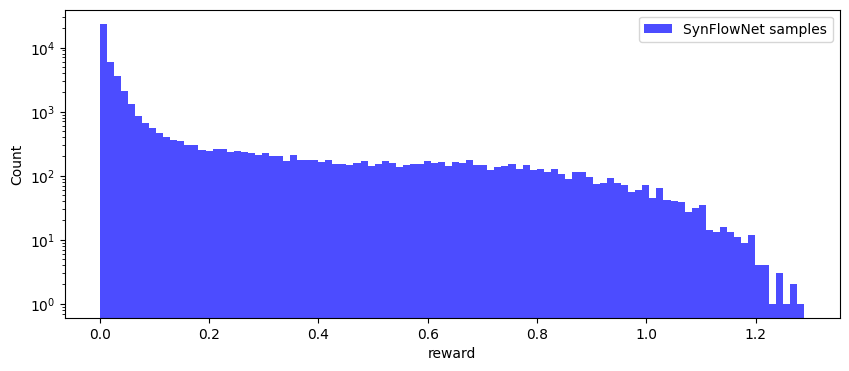

In [10]:
COL = "reward"
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(df[COL], bins=100, alpha=0.7, label="SynFlowNet samples", color="blue")
ax.set_yscale("log")
ax.set_xlabel(COL)
ax.set_ylabel("Count")
ax.legend()
fig.show()

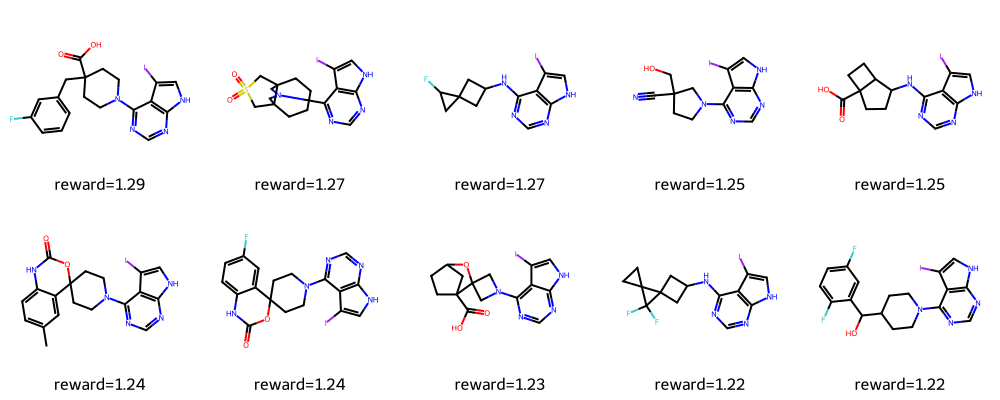

In [13]:
N = 10
top_df = df.sort_values(by=COL, ascending=False).head(N)

sfn_mols = [Chem.MolFromSmiles(smi) for smi in top_df["SMILES"]]
sfn_labels = [f"{COL}={c:.2f}" for c in top_df[COL]]
display(Chem.Draw.MolsToGridImage(sfn_mols, molsPerRow=5, subImgSize=(200, 200), legends=sfn_labels))